  Day Outlook  Temp Humidity    Wind Tennis
0  D1     Sun   Hot     High    Weak     No
1  D2     Sun   Hot     High  Strong     No
2  D3   Cloud   Hot     High    Weak    Yes
3  D4    Rain  Mild     High    Weak    Yes
4  D5    Rain  Cool   Normal    Weak    Yes
模型準確率: 0.6

分類報告:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



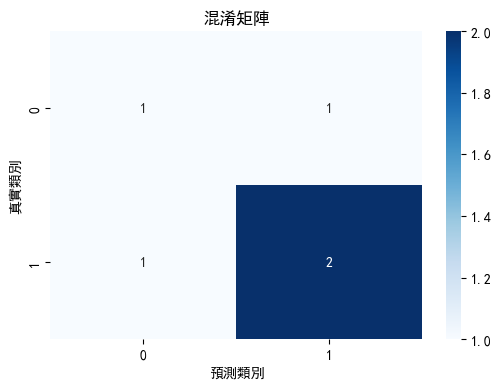

In [3]:
# 實驗四：貝氏分類（Gaussian Naive Bayes）- 天氣預測打球

# 步驟 1：導入必要的庫
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib as mpl

# 設定中文顯示
mpl.rcParams['font.family'] = 'SimHei'
mpl.rcParams['axes.unicode_minus'] = False

# 步驟 2：資料讀取與處理
df = pd.read_csv('weather_data.csv')
print(df.head())

# 將非數值型特徵轉換為數值
for col in ['Outlook', 'Temp', 'Humidity', 'Wind', 'Tennis']:
    le = pd.factorize(df[col])[0]
    df[col] = le

# 設定訓練目標
X = df[['Outlook', 'Temp', 'Humidity', 'Wind']]
y = df['Tennis']

# 步驟 3：資料切分與標準化
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 步驟 4：建立 Gaussian Naive Bayes 模型
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train_scaled, y_train)

# 預測與評估
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test_scaled)
print('模型準確率:', accuracy_score(y_test, y_pred))
print("\n分類報告:\n", classification_report(y_test, y_pred))

# 步驟 5：混淆矩陣視覺化
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('預測類別')
plt.ylabel('真實類別')
plt.title('混淆矩陣')
plt.show()